# Spherical harmonic transforms

This guide explains the mathematical formulation behind the scalar and vector
spherical harmonic transforms (SHT) in torch-harmonics, the available
normalization conventions, and the supported quadrature grids.

## 1. Spherical harmonics

The spherical harmonics $Y_l^m(\theta, \lambda)$ form a complete orthogonal
basis for square-integrable functions on the sphere $S^2$.  Here $\theta$
denotes colatitude ($0$ at the north pole, $\pi$ at the south pole) and
$\lambda$ denotes longitude ($0$ to $2\pi$).  They are separable into an
associated Legendre polynomial in colatitude and a complex exponential in
longitude:

$$
Y_l^m(\theta, \lambda) = P_l^m(\cos\theta)\,e^{im\lambda}
$$

where $l \ge 0$ is the **degree** and $0 \le m \le l$ is the **order**.

### 1.1 Normalization conventions

The normalization of the associated Legendre polynomials $P_l^m$ (and hence
of $Y_l^m$) is controlled by the `norm` parameter.  torch-harmonics
supports three conventions:

| `norm` | Convention | Inner-product property |
|---|---|---|
| `"ortho"` | **Orthonormal** (4$\pi$-normalized) | $\langle Y_l^m, Y_{l'}^{m'}\rangle = \delta_{ll'}\delta_{mm'}$ |
| `"schmidt"` | **Schmidt semi-normalized** | Carries $\sqrt{(l-m)!/(l+m)!}$ but omits $\sqrt{2l+1}$ |
| `"unnorm"` | **Unnormalized** | Bare three-term recurrence; not recommended for general use |

The inner product is $\langle f, g \rangle = \int_0^{2\pi}\int_0^{\pi}
f\,\bar{g}\,\sin\theta\,d\theta\,d\lambda$.

The **ortho** convention is the default and is standard in physics.  The
**Schmidt** convention is common in geomagnetism and gravity-field modelling.
The **unnorm** convention is provided for special-purpose work but is not
recommended because coefficient magnitudes grow with degree.

### 1.2 Condon--Shortley phase

The `csphase` parameter controls whether the Condon--Shortley phase factor
$(-1)^m$ is included in the associated Legendre polynomials.  When
`csphase=True` (default), the standard physics convention is used, in which
the raising/lowering operators have real, positive matrix elements.  Setting
`csphase=False` removes this factor, following the geodesy/geomagnetism
convention.

## 2. Forward scalar SHT

Given a real-valued signal $f(\theta, \lambda)$ sampled on the sphere, the
forward scalar SHT ({class}`~torch_harmonics.RealSHT`) computes the
spherical harmonic coefficients

$$
\hat{f}_l^m = \int_0^{2\pi} \int_0^{\pi}
    f(\theta, \lambda)\, \overline{Y_l^m(\theta, \lambda)}\,
    \sin\theta\; d\theta\; d\lambda
$$

In practice the integral is evaluated in two stages:

1. **Longitudinal FFT**: a real FFT along the $\lambda$ direction extracts
   the Fourier modes $\tilde{f}_m(\theta_k)$ at each quadrature node
   $\theta_k$.

2. **Legendre quadrature**: a Gauss-type quadrature contracts the Fourier
   modes with the associated Legendre polynomials and quadrature weights
   $q_k$:

$$
\hat{f}_l^m = 2\pi \sum_{k=0}^{N_\theta - 1}
    \tilde{f}_m(\theta_k)\, P_l^m(\cos\theta_k)\, q_k
$$

## 3. Inverse scalar SHT

Given complex spherical harmonic coefficients $\hat{f}_l^m$, the inverse
scalar SHT ({class}`~torch_harmonics.InverseRealSHT`) reconstructs the
real-valued signal on the sphere:

$$
f(\theta, \lambda) = \sum_{l=0}^{l_{\max}-1} \sum_{m=0}^{m_{\max}-1}
    \hat{f}_l^m\, Y_l^m(\theta, \lambda)
$$

The synthesis is carried out in two stages:

1. **Legendre synthesis**: contracts the coefficients with the associated
   Legendre polynomials to produce Fourier modes at each grid latitude:

$$
\tilde{f}_m(\theta_k) = \sum_{l=m}^{l_{\max}-1}
    \hat{f}_l^m\, P_l^m(\cos\theta_k)
$$

2. **Inverse FFT**: an inverse real FFT along the longitudinal direction
   reconstructs the spatial signal $f(\theta_k, \lambda_j)$.

```{note}
The inverse real FFT (C2R transform) expects the DC component ($m = 0$)
and, when `nlon` is even, the Nyquist component ($m = N_\lambda / 2$)
to be purely real.  The module zeros out the imaginary parts of these
components before calling the transform.
```

## 4. Quadrature grids

The accuracy of the SHT depends on the quadrature rule used for the
latitudinal integration.  torch-harmonics supports the following grid
types:

| `grid` | Quadrature | Poles included | Polynomial exactness |
|---|---|---|---|
| `"legendre-gauss"` | Gauss--Legendre | No | $2N_{\text{lat}} - 1$ |
| `"lobatto"` | Gauss--Lobatto | Yes (both) | $2N_{\text{lat}} - 3$ |
| `"equiangular"` | Clenshaw--Curtis | Yes (both) | $N_{\text{lat}} - 1$ (odd), $N_{\text{lat}}$ (even) |
| `"equiangular-trapezoidal"` | Extended trapezoidal | Yes (both) | -- |

The default is `"equiangular"`, which provides uniformly spaced latitudes
and is the most common choice for climate and weather applications.
`"legendre-gauss"` achieves the highest polynomial exactness per grid
point and is preferred when maximum accuracy at low resolution is needed.

## 5. Example: scalar SHT round-trip

In [1]:
import matplotlib.pyplot as plt
import torch

import torch_harmonics as th
from torch_harmonics.plotting import plot_sphere
from torch_harmonics.utils import load_mola_elevation

nlat, nlon = 128, 256
signal = load_mola_elevation(nlat, nlon).unsqueeze(0)

sht = th.RealSHT(nlat, nlon, grid="equiangular")
isht = th.InverseRealSHT(nlat, nlon, grid="equiangular")

# forward transform
coeffs = sht(signal)

# inverse transform
reconstructed = isht(coeffs)

err = (signal - reconstructed).abs().max().item()
print(f"coeffs shape: {coeffs.shape}")
print(f"Max reconstruction error: {err:.2e}")

coeffs shape: torch.Size([1, 64, 64])
Max reconstruction error: 3.40e-01


/opt/anaconda/envs/torch-harmonics/lib/python3.12/site-packages/torch_harmonics/truncation.py:168: UserWarning: Default SHT truncation changed in v0.9.0: equiangular/equiangular-trapezoidal grids now truncate to (nlat+1)//2. Specify lmax explicitly to override.
  lmax = lmax or _truncate_lmax(nlat, grid)


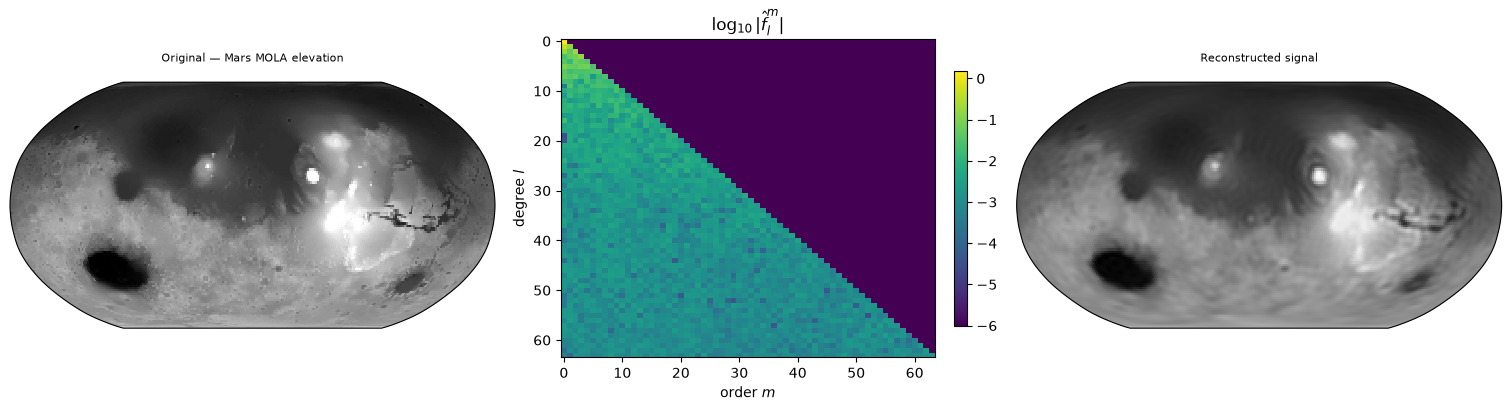

In [2]:
fig = plt.figure(figsize=(15, 4), layout="constrained")
subfigs = fig.subfigures(1, 3)

plot_sphere(signal[0], fig=subfigs[0], cmap="gray", title="Original — Mars MOLA elevation")

# spectral coefficients (keep as imshow)
ax = subfigs[1].add_subplot()
spec = coeffs[0].abs().log10().clamp(min=-6)
im = ax.imshow(spec, aspect="auto", cmap="viridis")
ax.set_title("$\\log_{10}|\\hat{f}_l^m|$")
ax.set_xlabel("order $m$")
ax.set_ylabel("degree $l$")
subfigs[1].colorbar(im, ax=ax, shrink=0.8)

plot_sphere(reconstructed[0], fig=subfigs[2], cmap="gray", title="Reconstructed signal")

plt.show()

## 6. Forward vector SHT

A tangential vector field on the sphere can be written as
$\mathbf{v}(\theta,\lambda) = v_\theta\,\hat{e}_\theta
+ v_\lambda\,\hat{e}_\lambda$.  The vector SHT
({class}`~torch_harmonics.RealVectorSHT`) decomposes this field into
**spheroidal** and **toroidal** spectral coefficients $\hat{s}_l^m$ and
$\hat{t}_l^m$:

$$
\hat{s}_l^m = \frac{1}{l(l+1)} \int_0^{2\pi} \int_0^{\pi}
    \left[
        v_\theta\, \frac{\partial \overline{Y_l^m}}{\partial \theta}
      + v_\lambda\, \frac{1}{\sin\theta}
                        \frac{\partial \overline{Y_l^m}}{\partial \lambda}
    \right] \sin\theta\; d\theta\; d\lambda
$$

$$
\hat{t}_l^m = \frac{1}{l(l+1)} \int_0^{2\pi} \int_0^{\pi}
    \left[
        v_\theta\, \frac{1}{\sin\theta}
                        \frac{\partial \overline{Y_l^m}}{\partial \lambda}
      - v_\lambda\, \frac{\partial \overline{Y_l^m}}{\partial \theta}
    \right] \sin\theta\; d\theta\; d\lambda
$$

As with the scalar SHT, the longitudinal integrals are evaluated with a
real FFT and the latitudinal integrals via Gauss-type quadrature using
the derivatives of the associated Legendre polynomials.

## 7. Inverse vector SHT

Given spheroidal and toroidal spectral coefficients, the inverse vector SHT
({class}`~torch_harmonics.InverseRealVectorSHT`) reconstructs the
tangential vector field:

$$
v_\theta(\theta,\lambda) = \sum_{l=0}^{l_{\max}-1} \sum_{m=0}^{m_{\max}-1}
    \left[
        \hat{s}_l^m\, \frac{\partial Y_l^m}{\partial \theta}
      + \hat{t}_l^m\, \frac{1}{\sin\theta}
                          \frac{\partial Y_l^m}{\partial \lambda}
    \right]
$$

$$
v_\lambda(\theta,\lambda) = \sum_{l=0}^{l_{\max}-1} \sum_{m=0}^{m_{\max}-1}
    \left[
        \hat{s}_l^m\, \frac{1}{\sin\theta}
                          \frac{\partial Y_l^m}{\partial \lambda}
      - \hat{t}_l^m\, \frac{\partial Y_l^m}{\partial \theta}
    \right]
$$

A Legendre synthesis contracts the coefficients with the derivatives of the
associated Legendre polynomials, followed by an inverse real FFT to recover
the spatial components.

## 8. Example: vector SHT round-trip

To demonstrate the vector SHT on a physically meaningful field, we compute
the **surface gradient** of the Mars MOLA elevation map spectrally: the
scalar SHT coefficients $\hat{f}_l^m$ are placed into the spheroidal
channel (with the toroidal channel set to zero), and the inverse vector SHT
synthesises $\nabla_H f$.  We then verify that a forward--inverse round-trip
recovers the same vector field.

We switch to the `legendre-gauss` grid here, which avoids the coordinate
singularity at the poles ($\sin\theta = 0$) and provides higher quadrature
exactness ($2N_{\text{lat}} - 1$).

In [3]:

# use legendre-gauss to avoid pole singularity
nlat_v, nlon_v = 128, 256
grid_v = "legendre-gauss"

# resample the Mars elevation onto the legendre-gauss grid via SHT
sht_eq = th.RealSHT(nlat, nlon, lmax=nlat_v, mmax=nlon_v // 2 + 1, grid="equiangular")
isht_lg = th.InverseRealSHT(nlat_v, nlon_v, lmax=nlat_v, mmax=nlon_v // 2 + 1, grid=grid_v)
signal_lg = isht_lg(sht_eq(signal))

# scalar SHT on the legendre-gauss grid
sht_v = th.RealSHT(nlat_v, nlon_v, grid=grid_v)
scalar_coeffs = sht_v(signal_lg)

# build gradient vector field: spheroidal = scalar coefficients, toroidal = 0
grad_coeffs = torch.zeros(1, 2, *scalar_coeffs.shape[1:], dtype=scalar_coeffs.dtype)
grad_coeffs[:, 0] = scalar_coeffs

# synthesise the gradient vector field
ivsht = th.InverseRealVectorSHT(nlat_v, nlon_v, grid=grid_v)
vector_field = ivsht(grad_coeffs)

# round-trip: forward vector SHT then inverse
vsht = th.RealVectorSHT(nlat_v, nlon_v, grid=grid_v)
coeffs = vsht(vector_field)
reconstructed = ivsht(coeffs)

err = (vector_field - reconstructed).abs().max().item()
print(f"vector field shape: {vector_field.shape}")
print(f"coeffs shape:       {coeffs.shape}")
print(f"Max reconstruction error: {err:.2e}")

vector field shape: torch.Size([1, 2, 128, 256])
coeffs shape:       torch.Size([1, 2, 128, 128])
Max reconstruction error: 1.91e-06


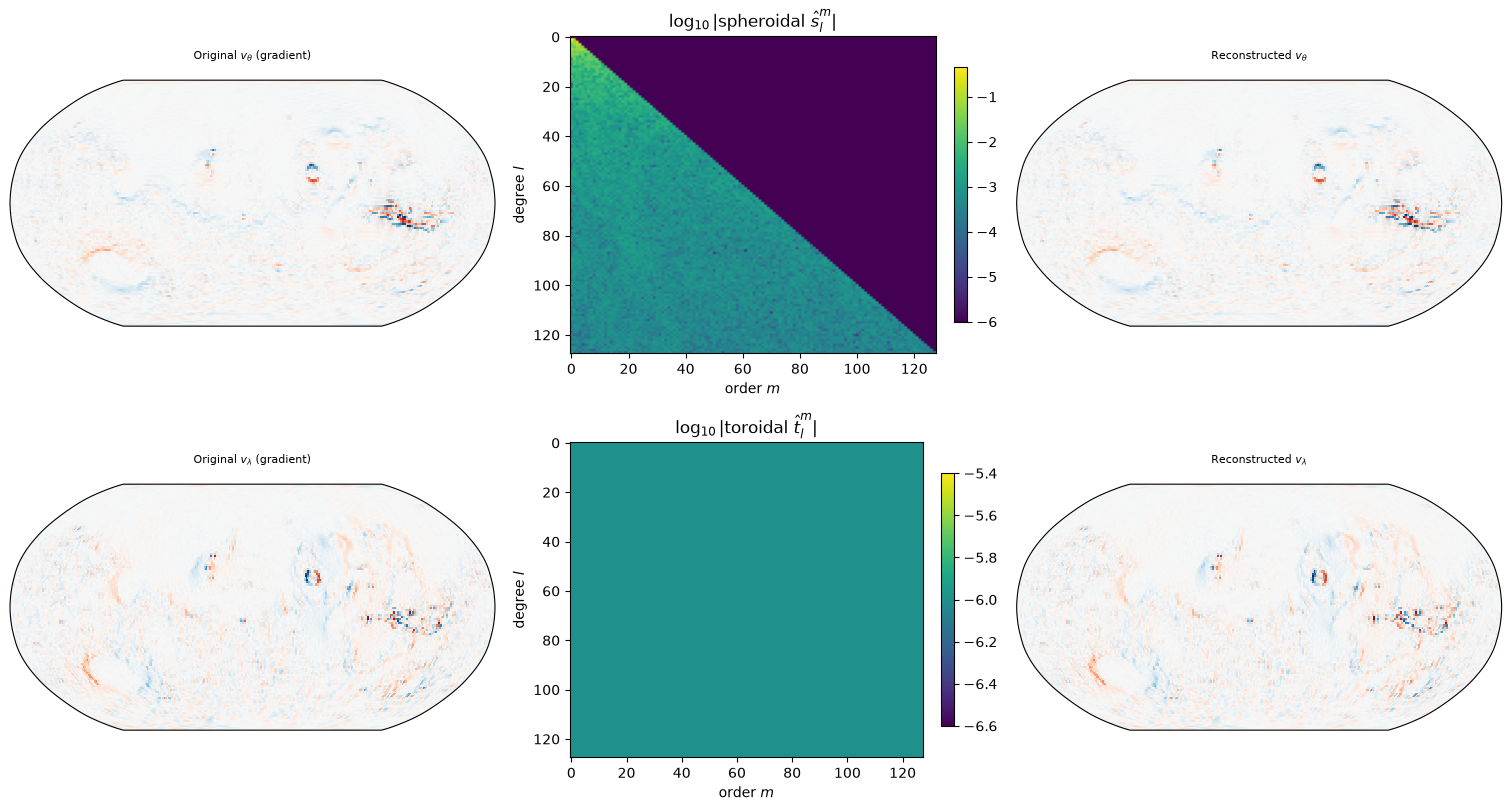

In [4]:
fig = plt.figure(figsize=(15, 8), layout="constrained")
subfigs = fig.subfigures(2, 3)

for i, (comp, label) in enumerate([(r"$v_\theta$", "spheroidal $\\hat{s}_l^m$"),
                                    (r"$v_\lambda$", "toroidal $\\hat{t}_l^m$")]):
    vmax = vector_field[0, i].abs().max().item()

    plot_sphere(vector_field[0, i], fig=subfigs[i, 0], cmap="RdBu",
                title=f"Original {comp} (gradient)", vmin=-vmax, vmax=vmax)

    # spectral coefficients (keep as imshow)
    ax = subfigs[i, 1].add_subplot()
    spec = coeffs[0, i].abs().log10().clamp(min=-6)
    im = ax.imshow(spec, aspect="auto", cmap="viridis")
    ax.set_title(f"$\\log_{{10}}|${label}$|$")
    ax.set_xlabel("order $m$")
    ax.set_ylabel("degree $l$")
    subfigs[i, 1].colorbar(im, ax=ax, shrink=0.8)

    plot_sphere(reconstructed[0, i], fig=subfigs[i, 2], cmap="RdBu",
                title=f"Reconstructed {comp}", vmin=-vmax, vmax=vmax)

plt.show()

## 9. cuFFT precision note

All SHT modules use **cuFFT** (via `torch.fft.rfft` / `torch.fft.irfft`)
for the longitudinal Fourier transform.  When running in **float16** or
**bfloat16** precision, cuFFT requires the transformed dimension (`nlon`)
to be a **power of two**.  If your grid does not satisfy this constraint and
the module is called inside a `torch.autocast` context, guard it with an
inner context that disables autocast:

```python
with torch.autocast(device_type="cuda", dtype=torch.float16):
    # ... other half-precision work ...
    with torch.autocast(device_type="cuda", enabled=False):
        coeffs = sht(signal.float())
```

## Summary

- The **scalar SHT** decomposes a function on the sphere into spherical
  harmonic coefficients $\hat{f}_l^m$ via FFT + Legendre quadrature.
  The inverse SHT reconstructs the signal from its coefficients.
- The **vector SHT** decomposes a tangential vector field into spheroidal
  and toroidal spectral coefficients using derivatives of the associated
  Legendre polynomials.
- Three **normalization conventions** (`ortho`, `schmidt`, `unnorm`) and
  optional **Condon--Shortley phase** are supported.
- Four **quadrature grids** are available, trading off accuracy and grid
  structure.

For the full parameter documentation, see
{class}`~torch_harmonics.RealSHT`,
{class}`~torch_harmonics.InverseRealSHT`,
{class}`~torch_harmonics.RealVectorSHT`, and
{class}`~torch_harmonics.InverseRealVectorSHT`.